### Métricas de Avaliação de Modelos - Classificação Binária

In [28]:
import matplotlib.pyplot as plt
from sklearn import metrics

Acurácia é uma das métricas mais diretas para se avaliar o desempenho de modelo. Ela define o quão acurado (não tem uma palavra melhor), um modelo está.

Para isso, é feito apenas um cálculo de quantos itens/predições um modelo acertou em relação a quantas ele fez.

In [29]:
def accuracy(y_true, y_pred):
    """
    Function to calculate accuracy
    
    :param y_true: list of true values
    :param y_pred: list of predicted values
    :return: accuracy score
    """

    correct_counter = 0
    
    for yt, yp in zip(y_true, y_pred):
        if yt == yp: 
            correct_counter += 1

    return correct_counter / len(y_true)

Apesar de muito direto, essa métrica possui maior confiabildiade quando os dados estão distribuidos de forma equilibrada entre as categorias que estamos tentando prever. 

Caso isso não aconteça, ou seja, o número de amostras em uma classe supere (em muito) o número de amostras de uma outra classe, a acurácia n]ap se mostra mais representativa o suficiente e temos que adotar um nova métrica para analisar o desempenho dos modelos. 

Nessa situação, é mais interessante calcularmos a Precisão (_Precision_)

Antes disso, precisamos entender alguns termos, como:

- True Positives (TP): Ocorre quando nosso modelo corretamente prevê uma classe considerada positiva (1)
- True Negatives (TN): Ocorre quando nosso modelo corretamente prevê uma classe considerada negativa (0)

Com essas duas categorias (TP e TN), estamos contando as informações que o nosso modelo preveu/classificou corretamente.

In [30]:
def true_positive(y_true, y_pred):
    """
    Function to calculate true positives
    
    :param y_true: list of true values
    :param y_pred: list of predicted values
    :return: number of true positives
    """


    tp = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            tp += 1
    return tp

def true_negatives(y_true, y_pred):
    """
    Function to calculate true negatives

    :param y_true: list of true values
    :param y_pred: list of predicted values
    :return: number of true negatives
    """

    tn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 0 and yp == 0:
            tn += 1
    return tn

Mas também, precisamos analisar as situações em que nosso modelo erra. Agrupamos essas situações em:

- False Positives (FP): Ocorre quando nosso modelo, de forma incorreta, prevê uma classe como sendo positiva. Ou seja, prevemos positivo mas não era. 
- False Negatives (FN): Ocorre quando nosso modelo, de forma incorreta, prevê uma classe como sendo negativa. Ou seja, prevemos negativo mas não era

In [31]:
def false_positive(y_true, y_pred):
    """
    Function to calculate false positives
    
    :param y_true: list of true values
    :param y_pred: list of predicted values
    :return: number of false positives
    """


    fp = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 0 and yp == 1:
            fp += 1
    return fp

def false_negatives(y_true, y_pred):
    """
    Function to calculate false negatives

    :param y_true: list of true values
    :param y_pred: list of predicted values
    :return: number of false negatives
    """

    fn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 0:
            fn += 1
    return fn

A partir desses agrupamentos podemos também reescrever o cálculo de acurácia, sendo ele:

In [32]:
def accuracy_v2(y_true, y_pred):
    """
    Function to calculate accuracy using tp/tn/fp/fn

    :param y_true: list of true values
    :param y_pred: list of predicted values
    :return: accuracy score
    """


    tp = true_positive(y_true, y_pred)
    fp = false_positive(y_true, y_pred)
    fn = false_negatives(y_true, y_pred)
    tn = true_negatives(y_true, y_pred)

    correctly_predicted = tp + tn
    total_predictions = tp + tn + fp + fn
    accuracy_score = correctly_predicted / total_predictions

    return accuracy_score

Retomando a ideia de Precisão (_Precision_), temos que essa métrica indica a corretude do nosso modelo ao tentar identificar amostras positivas (1), ou de forma mais genérica, ao tentar identificar amostras consideradas de uma classe pré-escolhida. Para isso, calcula-se a relação entre as amostras que de fato eu previ corretamente para essa classe e a quantidade de previsões que eu fiz para essa classe, considerando previsões certas e erradas. 

Assim, entendemos o quão precisos fomos nas nossas previsões.

In [33]:
def precision(y_true, y_pred):
    """
    Function to calculate precision

    :param y_true: list of true values
    :param y_pred: list of predicted values
    :return: precision score
    """


    tp = true_positive(y_true, y_pred)
    fp = false_positive(y_true, y_pred)

    precision = tp / (tp+fp)

    return precision

Também podemos calcular o que chamamos de Recall, a porcentagem de acertos que eu tive na minha previsão em relação ao total de dados disponíveis daquela classe (considerando as que eu previ certa (TP) e as que eu previ errada, como sendo de outra classe (FN)). Essa métrica pode ser calculada da seguinte forma: 

In [34]:
def recall(y_true, y_pred):
    """
    Function to calculate recall

    :param y_true: list of true values
    :param y_pred: list of predicted values
    :return: recall score
    """


    tp = true_positive(y_true, y_pred)
    fn = false_negatives(y_true, y_pred)

    precision = tp / (tp+fn)

    return precision

De certa forma, um bom modelo possui tanto a _Precision_ como o _Recall_ elevados. Mas são metricas que demandam muita atenção e seu entendimento se está bom ou ruim, além do número, está estritamente relacionado com o problema de negócio enfrentado. 

É preciso pensar considerando na situação que estamos nos deparando, ou seja, o business dos dados, qual seria o impacto de um falso positivo (FP) e de um falso negativo (FN) para a resolução do problema empresarial/social.

Nessa situação, nós podemos trabalhar com a alteração do threshould. Para entender melhor esse conceito, precisamos olhar para a probabilidade na predição ao invés do valor previsto (que em geral é calculado com um threshould de 0.5).

In [35]:
y_true = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

y_pred = [0.02638412, 0.11114267, 0.31620708,
    0.0490937, 0.0191491, 0.17554844,
    0.15952202, 0.03819563, 0.11639273,
    0.079377, 0.08584789, 0.39095342,
    0.27259048, 0.03447096, 0.04644807,
    0.03543574, 0.18521942, 0.05934905,
    0.61977213, 0.33056815]

In [36]:
precisions = []
recalls = []

thresholds = [0.0490937 , 0.05934905, 0.079377,
 0.08584789, 0.11114267, 0.11639273,
 0.15952202, 0.17554844, 0.18521942,
 0.27259048, 0.31620708, 0.33056815,
 0.39095342, 0.61977213]

for i in thresholds:
    temp_prediction = [1 if x >= i else 0 for x in y_pred]
    p = precision(y_true, temp_prediction)
    r = recall(y_true, temp_prediction)
    precisions.append(p)
    recalls.append(r)

O threshold é um delimitador. Se a probabilidade do valor previsto ser 1, estiver acima do threshold então temos que de fato o valor previsto será 1. Se estiver abaixo do threshold então o valor será previsto como 0

É bem difícil escolher um threshold que dá um bom equilibro entre boa precisão e recall. De forma que se o threshold for muito alto, nós temos uma pequena quantidade de Verdadeiro Positivo e de Falso Negativos, o que diminui o *Recall* e aumenta a *Precision*. Se reduzirmos muito o threshold, haverá um aumento de Falso Positivos e uma queda na *Precision*

Text(0, 0.5, 'Precision')

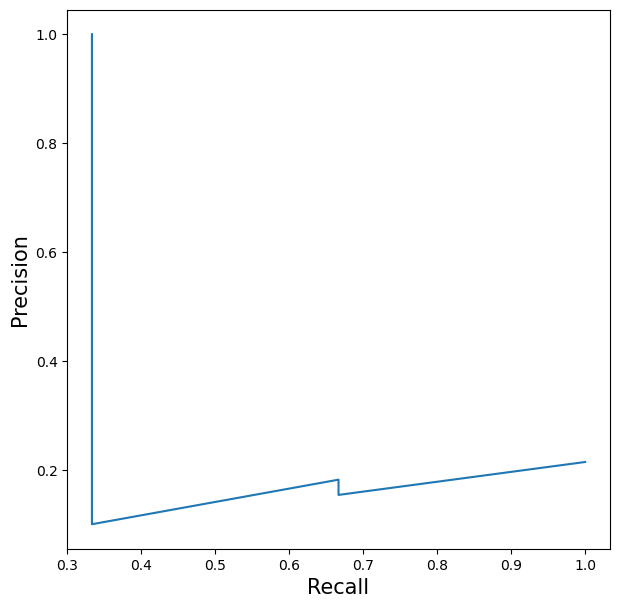

In [37]:
plt.figure(figsize=(7,7))
plt.plot(recalls, precisions)
plt.xlabel('Recall', fontsize=15)
plt.ylabel('Precision', fontsize=15)

Agora, há também uma métrica que combina tanto _Precision_ como _Recall_, chamada de F1 Score. Essa métrica é uma simples média harmônica de _precision_ e _recall_, que podemos representar como:

In [38]:
def f1(y_true, y_pred):

    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)

    score = 2*p*r / (p+r)

    return score

In [39]:
y_true = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

y_pred = [0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

In [40]:
metrics.f1_score(y_true, y_pred)

0.5714285714285715

Dessa forma, ao invés de olharmos para _precision_ e _recall_, podemos sempre olhar para o _F1 Score_. 

Lembrete: Sempre que estivermos trabalhando com datasets desbalanceados (skewed), devemos olhar para o F1 Score (ou a _precision_ e _recall_) ao invés da _Acurácia_

Vamos nos aprofundar um pouco mais agora que temos os termos base estabelecidos. 

A Taxa de Verdadeiros Positivos (True Positive Rate - TPR) é outro nome para _recall_, ou também conhecida como _Sensitivity_. Em complemento, temos que 1 - TPR é chamado de _Specificity_ ou Taxa de Verdadeiros Negativos (True Negative Rate - TNR)

In [41]:
def tpr(y_true, y_pred):
    return recall(y_true, y_pred)

A Taxa de Falsos Positivos (False Positive Rate - FPR) é definida como FPR = FP / (TN + FP)

In [42]:
def fpr(y_true, y_pred):
    fp = false_positive(y_true, y_pred)
    tn = true_negatives(y_true, y_pred)

    return fp / (tn+fp)

Imaginando um problema de previsão, vamos calcular os valores de TPR (True Positive Rate) e de FPR (False Positive Rate)

In [43]:
tpr_list = []
fpr_list = []

y_true = [0, 0, 0, 0, 1, 0, 1, 
          0, 0, 1, 0, 1, 0, 0, 1]

y_pred = [0.1, 0.3, 0.2, 0.6, 0.8, 0.05, 
          0.9, 0.5, 0.3, 0.66, 0.3, 0.3, 
          0.85, 0.15, 0.99]

thresholds = [0, 0.1, 0.3, 0.3, 0.4, 0.5,
              0.6, 0.7, 0.8, 0.85, 0.9, 0.99, 1.0]

for thresh in thresholds:
    temp_pred = [1 if x >= thresh else 0 for x in y_pred]
    temp_tpr = tpr(y_true, temp_pred)
    temp_fpr = fpr(y_true, temp_pred)

    tpr_list.append(temp_tpr)
    fpr_list.append(temp_fpr)

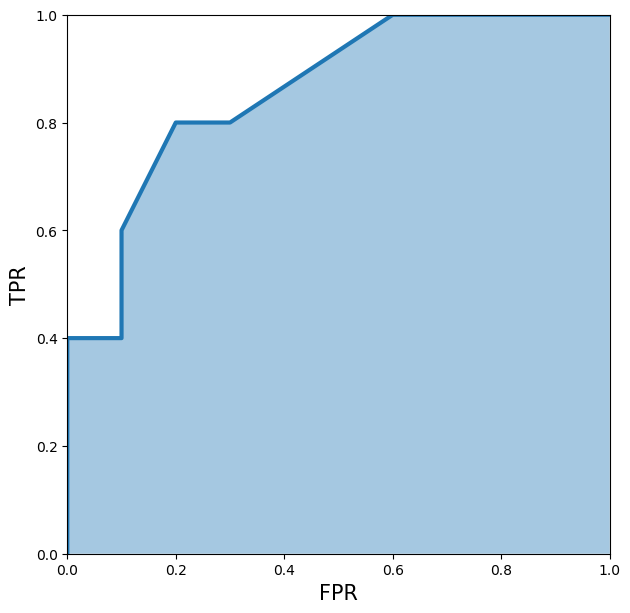

In [44]:
plt.figure(figsize=(7, 7))
plt.fill_between(fpr_list, tpr_list, alpha=0.4)
plt.plot(fpr_list, tpr_list, lw=3)
plt.xlim(0, 1.0)
plt.ylim(0, 1.0)
plt.xlabel('FPR', fontsize=15)
plt.ylabel('TPR', fontsize=15)
plt.show()

Essa curva que temos no gráfico é conhecida como Receiver Operating Characteristic (ROC) e se calcularmos a área abaixo da curva (integral) temos uma outra métrica conhecida como AUC (Area Under ROC Curve - Area Under Curve) que varia de 0 a 1

* AUC = 1 significa que temos um modelo perfeito, mas isso é bem suspeito. Significa que houve algum erro no processo de validação e que precisamos revisar o processamento dos dados e a pipeline de validação
* AUC = 0 significa que o modelo é bem ruim  (ou muito bom). Podemos tentar inverter a probabilidade das previsões, ou seja, se a probabilidade de uma classe positiva é _x_, podemos substituir por _1 - x_. Mas em geral, também é um indicativo que houve algum erro no processamento de dados e na pipeline de validação.
* AUC = 0.5 indica que as predições são aleatórias.

_Observação:_ Entre 0 e 0.5 pode ser que houve uma inversão de classes   

Nós podemos usar a curva ROC para escolher o threshold que mencionamos. Ela mostra como o threshold impacta a taxa de falsos positivos e a taxa de verdadeiros positivos e, em contra ponto, falsos positivos e verdadeiros positivos. De forma que se quisermos mais falsos positivos, precisamos ter um alto threshold.  


**Mas precisamos lembrar que a escolha do threshold está muito mais relacionada com o problema de negócio, seus trade-offs e os dados**

In [45]:
tp_list = []
fp_list = []

y_true = [0, 0, 0, 0, 1, 0, 1,
        0, 0, 1, 0, 1, 0, 0, 1]

y_pred = [0.1, 0.3, 0.2, 0.6, 0.8, 0.05, 
          0.9, 0.5, 0.5, 0.66, 0.3, 0.2, 
          0.85, 0.15, 0.99]

thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5,
              0.6, 0.7, 0.8, 0.85, 0.9, 0.99, 1.0]

for thresh in thresholds:
    temp_pred = [1 if x >= thresh else 0 for x in y_pred]
    temp_tp = true_positive(y_true, temp_pred)
    temp_fp = false_positive(y_true, temp_pred)

    tp_list.append(temp_fp)
    fp_list.append(temp_fp)

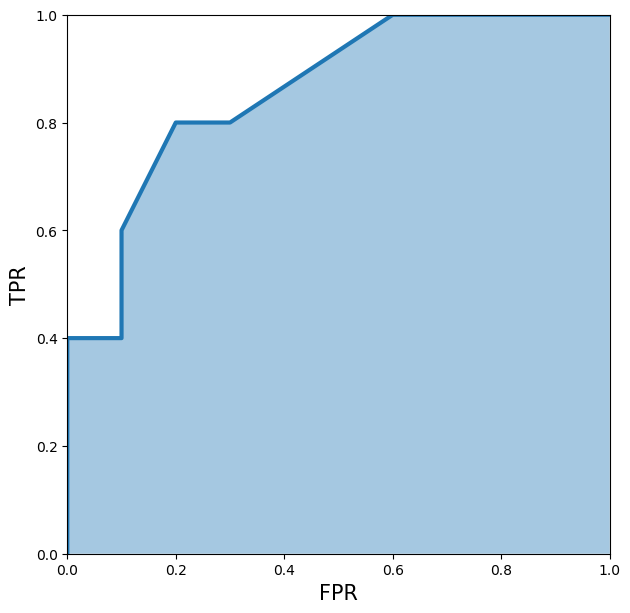

In [46]:
plt.figure(figsize=(7, 7))
plt.fill_between(fpr_list, tpr_list, alpha=0.4)
plt.plot(fpr_list, tpr_list, lw=3)
plt.xlim(0, 1.0)
plt.ylim(0, 1.0)
plt.xlabel('FPR', fontsize=15)
plt.ylabel('TPR', fontsize=15)
plt.show()

Na maioria das vezes, o canto superior esquerdo da curva pode nos dar um bom valor de threshold. Nesse caso, 0.6.